![alt text](c83ea3fb-67c1-4588-8b75-91a600453493.png)

## 一个简单的机器学习例子
Scikit-learn（简称 Sklearn）是一个开源的机器学习库，建立在 NumPy、SciPy 和 matplotlib 这些科学计算库之上，提供了简单高效的数据挖掘和数据分析工具。

Scikit-learn 包含了许多常见的机器学习算法，包括：

- 线性回归、岭回归、Lasso回归
- 支持向量机（SVM）
- 决策树、随机森林、梯度提升树
- 聚类算法（如K-Means、层次聚类、DBSCAN）
- 降维技术（如PCA、t-SNE）
- 神经网络

接下来我们通过一个简单的分类任务——使用鸢尾花数据集（Iris Dataset）来演示机器学习的流程，鸢尾花数据集是一个经典的数据集，包含 150 个样本，描述了三种不同类型的鸢尾花的花瓣和萼片的长度和宽度。

----
### 1. 导入必要的库

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

----
### 2. 加载数据

In [29]:
# 加载鸢尾花数据集
iris = load_iris()

# 将数据转化为 pandas , DataFrame
X = pd.DataFrame(iris.data , columns = iris.feature_names)      # 特征数据
y = pd.Series(iris.target)          # 标签数据

# 显示前五行                                                    
print(X.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


----
### 3. 数据集划分

In [30]:
# 划分训练集和测试集 , 通常用 70% 训练集 , 30% 测试集的比例
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , 
random_state = 42)

----
### 4. 特征缩放(标准化)
许多机器学习算法都依赖于特征的尺度，特别是像 K 最近邻算法。为了确保每个特征的均值为 0，标准差为 1，我们使用标准化来处理数据：

In [31]:
# 标准化特征
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

----
### 5.选择模型并训练
我们选择 K 最近邻算法（K-Nearest Neighbors, KNN）作为我们的分类模型。KNN 是一种简单的监督学习算法，它通过计算新样本与训练样本之间的距离来进行分类。

In [32]:
# 创建 KNN 分类器
knn = KNeighborsClassifier(n_neighbors=3)

# 训练模型
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

-----
### 6. 模型评估

In [33]:
# 预测测试集
y_pred = knn.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test , y_pred)
print(f"模型准确率:{accuracy:.2f}")

模型准确率:1.00


----
### 7.可视化结果
以通过可视化来进一步了解模型的表现，尤其是在多维数据集的情况下。例如，你可以用二维图来显示 KNN 分类的结果（不过在这里需要对数据进行降维，简化为二维）

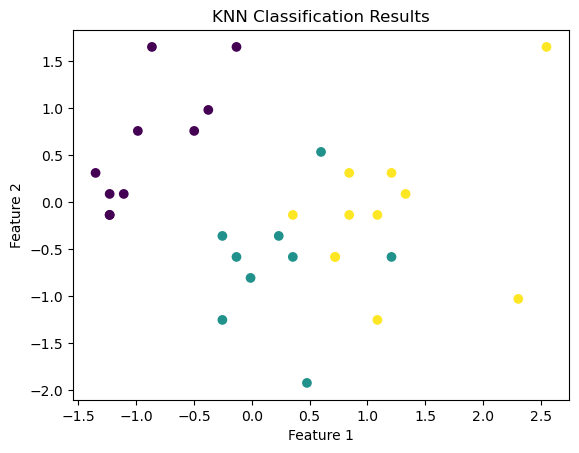

In [34]:
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='viridis', marker='o')
plt.title("KNN Classification Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()